# AI vs Human Essay Analysis

**Dataset:** ~500K Essays (Human vs AI Generated)  
**Fixes applied:** performance (no NLTK tokenizer on full dataset), `df['label']` created at load time, `import textstat` corrected, balanced dataset propagated consistently, ML classifier added, LinkedIn cards use computed values, Power BI exports enriched with predictions.

 # Step 1 — Load & Explore Data

STEP 1: LOAD & EXPLORE DATA

✓ Dataset loaded: 487,235 essays | shape (487235, 3)
  Memory: 1174.3 MB
  Columns: ['text', 'generated', 'label']
  Dtypes:
text          object
generated    float64
label         object
dtype: object

Missing values:
text         0
generated    0
label        0
dtype: int64

Duplicate rows: 0 (0.00%)

Label distribution:
  Human (0.0): 305,797  (62.76%)
  AI (1.0): 181,438  (37.24%)

Balance ratio: 0.59  →  Slightly imbalanced ⚠


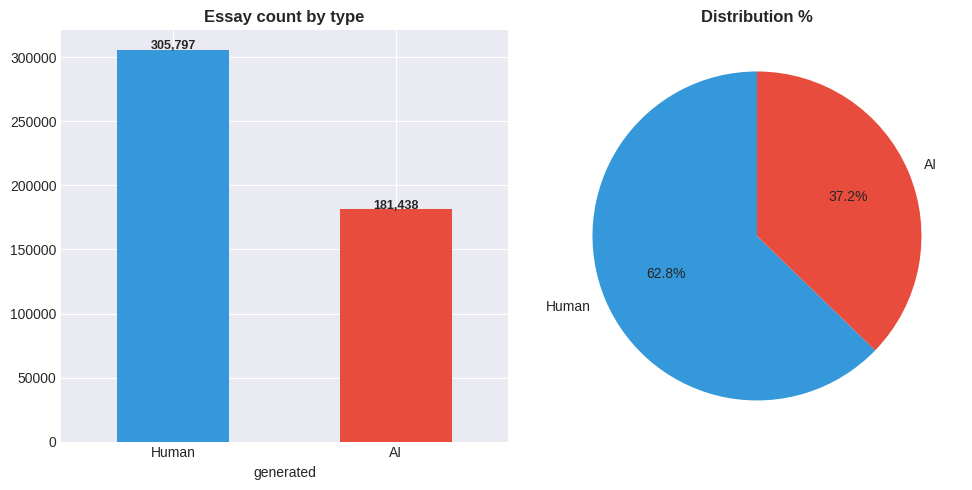


✓ STEP 1 COMPLETE


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings, os
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
os.makedirs('powerbi_exports', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("="*70)
print("STEP 1: LOAD & EXPLORE DATA")
print("="*70)

df = pd.read_csv('/kaggle/input/ai-vs-human-text/AI_Human.csv')

# ── FIX 1: create 'label' immediately after loading ──────────────────────────
# Several cells below use df['label']. Without this line they crash with KeyError.
df['label'] = df['generated'].map({0: 'Human', 1: 'AI'})

print(f"\n✓ Dataset loaded: {len(df):,} essays | shape {df.shape}")
print(f"  Memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Dtypes:\n{df.dtypes}")

# Quality checks
missing = df.isnull().sum()
dupes   = df.duplicated().sum()
print(f"\nMissing values:\n{missing}")
print(f"\nDuplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)")

# Label distribution
label_counts = df['generated'].value_counts().sort_index()
label_pct    = df['generated'].value_counts(normalize=True).sort_index() * 100
print("\nLabel distribution:")
for lbl, cnt in label_counts.items():
    print(f"  {'Human' if lbl==0 else 'AI'} ({lbl}): {cnt:,}  ({label_pct[lbl]:.2f}%)")

balance = label_counts.min() / label_counts.max()
print(f"\nBalance ratio: {balance:.2f}  →  ", end="")
print("Well-balanced ✓" if balance > 0.8 else ("Slightly imbalanced ⚠" if balance > 0.5 else "Imbalanced ⚠"))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
label_counts.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c'])
axes[0].set_title('Essay count by type', fontweight='bold')
axes[0].set_xticklabels(['Human','AI'], rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v+500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
axes[1].pie(label_counts, labels=['Human','AI'], autopct='%1.1f%%',
            colors=['#3498db','#e74c3c'], startangle=90)
axes[1].set_title('Distribution %', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step1_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ STEP 1 COMPLETE")


## Optional — Balance Dataset

In [2]:
print("="*70)
print("BALANCING DATASET (optional — run only if needed)")
print("="*70)

df_original = df.copy()

df_human = df[df['generated'] == 0]
df_ai    = df[df['generated'] == 1]

if len(df_human) > len(df_ai):
    df_human = df_human.sample(n=len(df_ai), random_state=42)
    print(f"Undersampled Human: {len(df_original[df_original.generated==0]):,} → {len(df_ai):,}")
else:
    df_ai = df_ai.sample(n=len(df_human), random_state=42)
    print(f"Undersampled AI: {len(df_original[df_original.generated==1]):,} → {len(df_human):,}")

# ── FIX 2: reassign df AND recreate label so all downstream cells stay consistent
df = pd.concat([df_human, df_ai], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df['label'] = df['generated'].map({0: 'Human', 1: 'AI'})   # recreate after concat

print(f"\n✓ Balanced dataset: {len(df):,} essays ({df['generated'].value_counts().to_dict()})")
print("  'df' now points to balanced data. 'df_original' keeps the full dataset.")


BALANCING DATASET (optional — run only if needed)
Undersampled Human: 305,797 → 181,438

✓ Balanced dataset: 362,876 essays ({0.0: 181438, 1.0: 181438})
  'df' now points to balanced data. 'df_original' keeps the full dataset.


## Step 2 — Text Feature Engineering

In [6]:

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "textstat", "-q"], check=True)

import textstat

import textstat   # FIX 3: was 'from textstat import textstat' which raises ImportError

print("="*70)
print("STEP 2: TEXT FEATURE ENGINEERING")
print("="*70)

# ── Fast text cleaning (no NLTK dependency) ───────────────────────────────────
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)
print("✓ Text cleaned")

# ── Fast feature extraction ───────────────────────────────────────────────────
# FIX 4: use regex/split instead of nltk tokenisers — ~30x faster on large datasets
def extract_features(text):
    if not isinstance(text, str) or not text.strip():
        return {}

    # words: simple whitespace split is enough for counts
    words       = text.split()
    words_alpha = [w.lower().strip(string.punctuation) for w in words if w.strip(string.punctuation).isalpha()]
    word_count  = len(words)

    # sentences: split on . ! ?
    sentences      = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    sentence_count = max(len(sentences), 1)

    # paragraphs
    paragraphs      = [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]
    paragraph_count = max(len(paragraphs), 1)

    unique_words = set(words_alpha)
    word_freq    = Counter(words_alpha)
    hapax        = sum(1 for c in word_freq.values() if c == 1)

    avg_word_length      = round(np.mean([len(w) for w in words_alpha]), 3) if words_alpha else 0
    avg_sentence_length  = round(word_count / sentence_count, 3)
    avg_paragraph_length = round(word_count / paragraph_count, 3)
    lexical_diversity    = round(len(unique_words) / len(words_alpha), 4) if words_alpha else 0
    hapax_ratio          = round(hapax / len(words_alpha), 4) if words_alpha else 0
    long_word_ratio      = round(sum(1 for w in words_alpha if len(w) > 6) / max(len(words_alpha),1), 4)

    # Punctuation
    comma_count       = text.count(',')
    period_count      = text.count('.')
    exclamation_count = text.count('!')
    question_count    = text.count('?')
    semicolon_count   = text.count(';')
    punct_density     = round(sum(1 for c in text if c in string.punctuation) / max(len(text),1), 4)
    comma_per_sent    = round(comma_count / sentence_count, 3)

    feats = {
        'char_count': len(text),
        'word_count': word_count,
        'unique_words': len(unique_words),
        'sentence_count': sentence_count,
        'paragraph_count': paragraph_count,
        'avg_word_length': avg_word_length,
        'avg_sentence_length': avg_sentence_length,
        'avg_paragraph_length': avg_paragraph_length,
        'lexical_diversity': lexical_diversity,
        'hapax_ratio': hapax_ratio,
        'long_word_ratio': long_word_ratio,
        'comma_count': comma_count,
        'period_count': period_count,
        'exclamation_count': exclamation_count,
        'question_count': question_count,
        'semicolon_count': semicolon_count,
        'punctuation_density': punct_density,
        'comma_per_sentence': comma_per_sent,
    }

    # Readability — textstat is row-wise but unavoidable; ~2 min on 500K
    try:
        feats['flesch_reading_ease']      = textstat.flesch_reading_ease(text)
        feats['flesch_kincaid_grade']     = textstat.flesch_kincaid_grade(text)
        feats['gunning_fog']              = textstat.gunning_fog(text)
        feats['smog_index']               = textstat.smog_index(text)
        feats['automated_readability']    = textstat.automated_readability_index(text)
        feats['coleman_liau']             = textstat.coleman_liau_index(text)
        feats['dale_chall']               = textstat.dale_chall_readability_score(text)
    except Exception:
        pass

    return feats

# Process in chunks for progress feedback
print("\nExtracting features (progress every 50k rows)...")
CHUNK = 50_000
rows  = []
for i in range(0, len(df), CHUNK):
    rows.extend(df['text_clean'].iloc[i:i+CHUNK].apply(extract_features).tolist())
    print(f"  {min(i+CHUNK, len(df)):,} / {len(df):,}")

feat_df = pd.DataFrame(rows)

# Clip outliers at 99th percentile
num_cols = feat_df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    feat_df[col] = feat_df[col].clip(upper=feat_df[col].quantile(0.99))

df = pd.concat([df, feat_df], axis=1)
print(f"\n✓ {feat_df.shape[1]} features added to df")
print("\n✓ STEP 2 COMPLETE")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.8 MB/s eta 0:00:00
STEP 2: TEXT FEATURE ENGINEERING
✓ Text cleaned

Extracting features (progress every 50k rows)...
  50,000 / 362,876
  100,000 / 362,876
  150,000 / 362,876
  200,000 / 362,876
  250,000 / 362,876
  300,000 / 362,876
  350,000 / 362,876
  362,876 / 362,876

✓ 25 features added to df

✓ STEP 2 COMPLETE


## Step 2b — Visualisations & Comparison

VISUALISATIONS: Human vs AI comparison


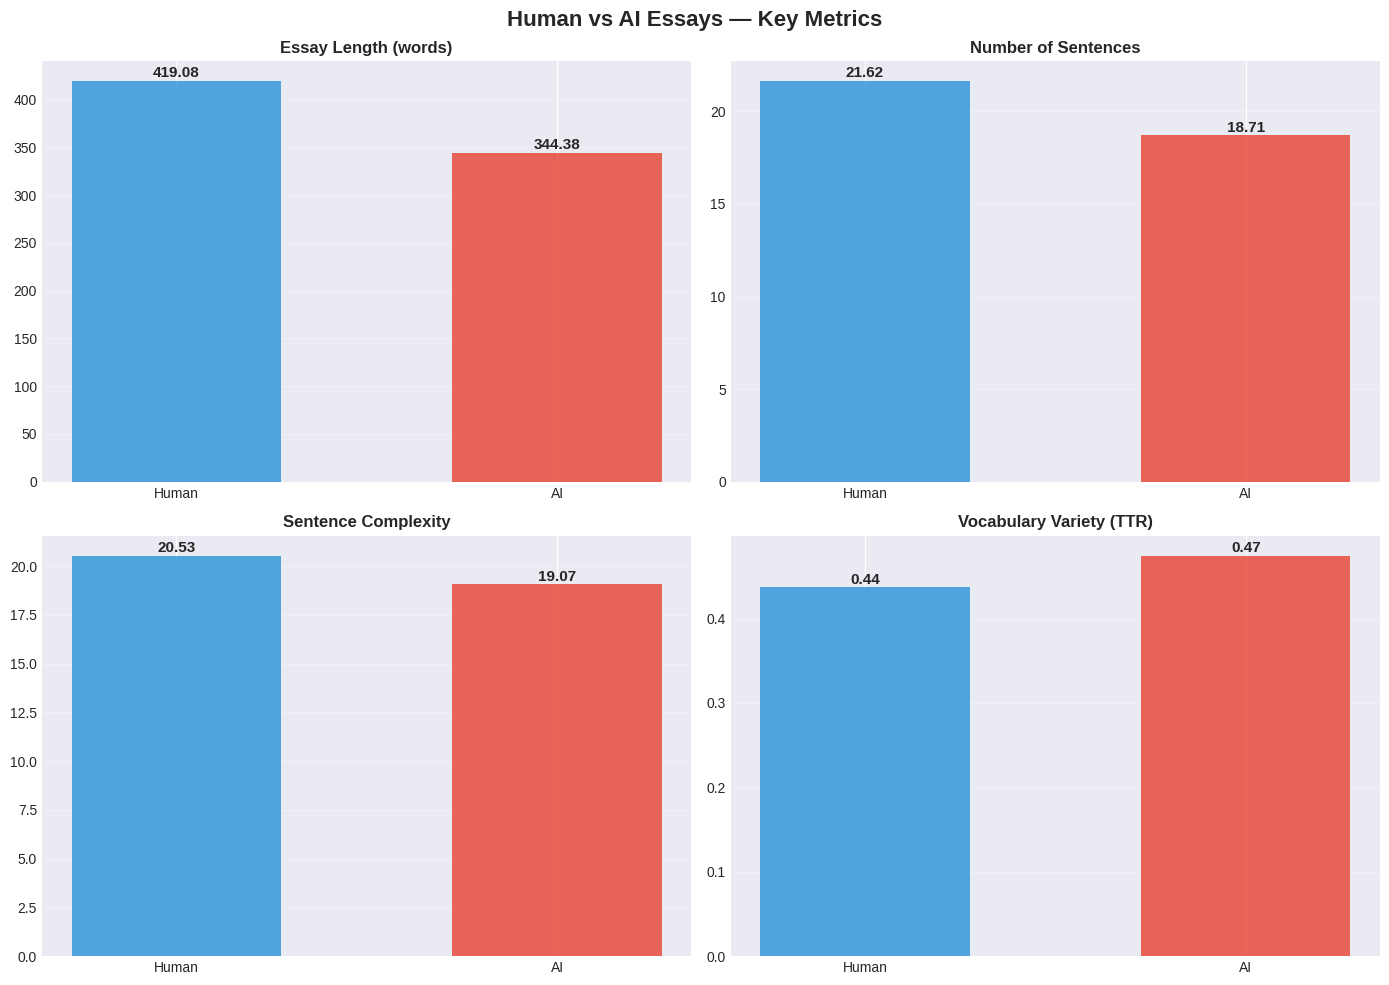

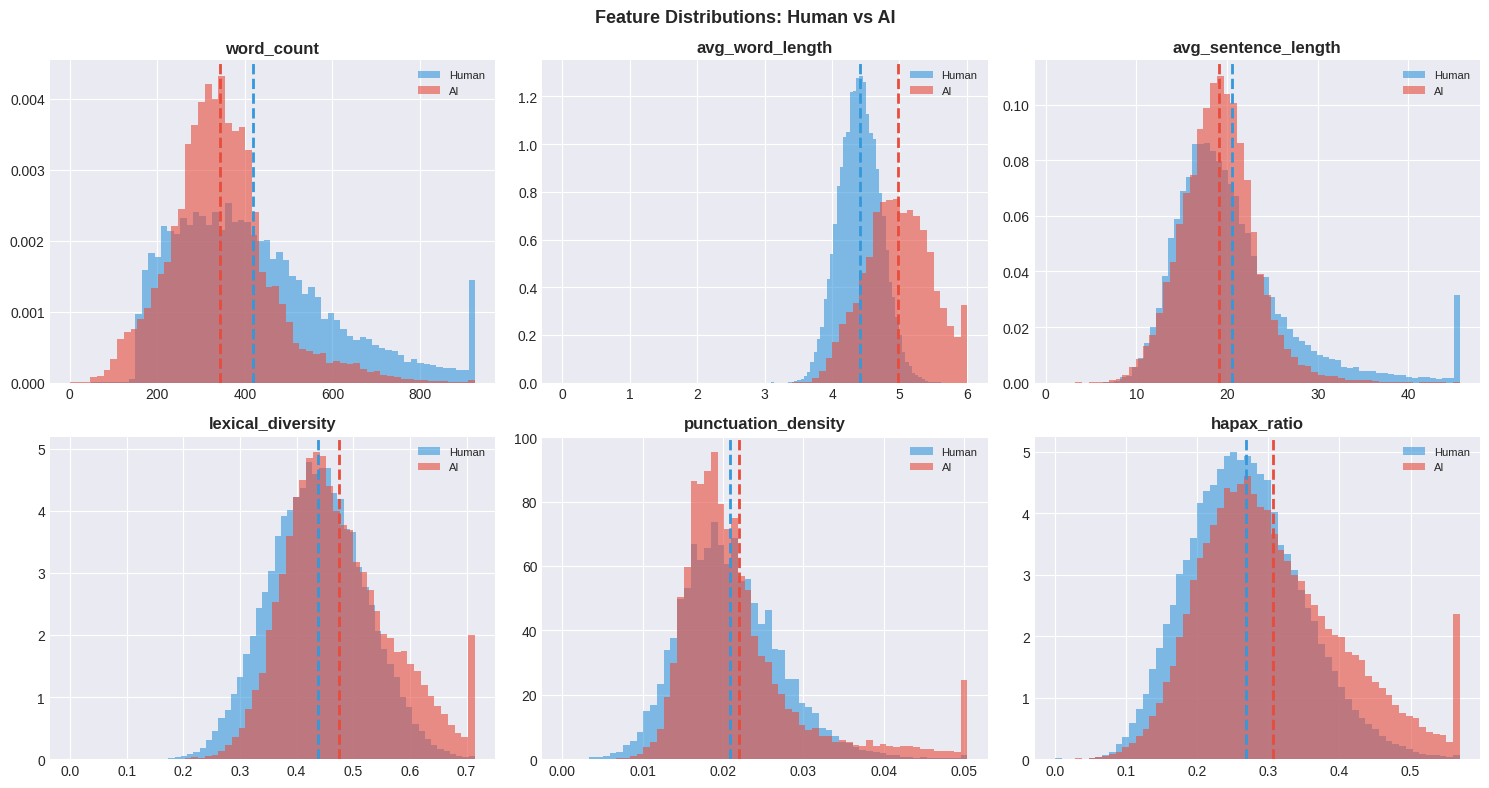

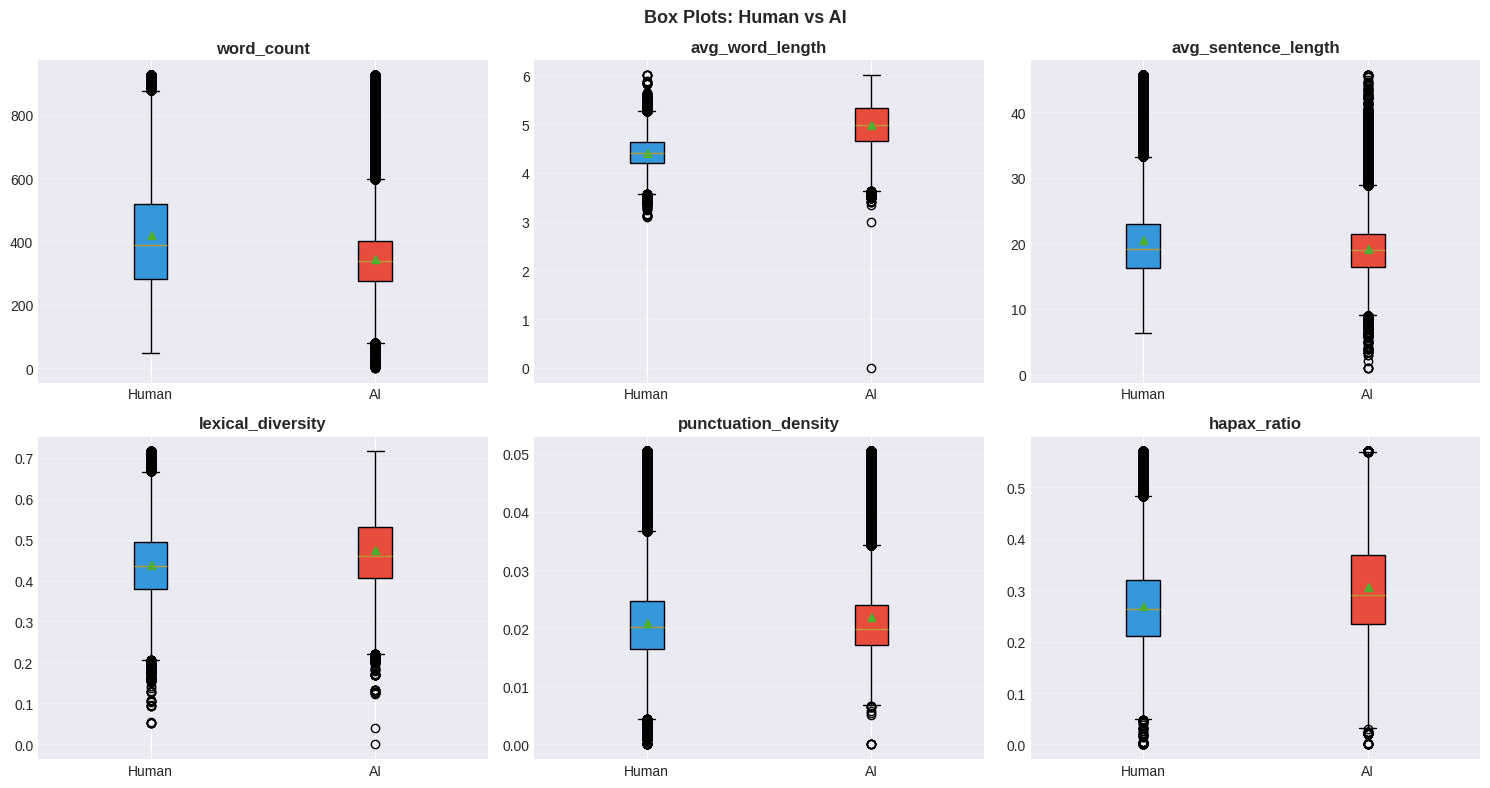


✓ Visualisations saved


In [7]:
print("="*70)
print("VISUALISATIONS: Human vs AI comparison")
print("="*70)

human_df = df[df['label'] == 'Human']
ai_df    = df[df['label'] == 'AI']

# ── 4-panel bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Human vs AI Essays — Key Metrics', fontsize=16, fontweight='bold')

panels = [
    ('word_count',        'Essay Length (words)',    axes[0,0]),
    ('sentence_count',    'Number of Sentences',     axes[0,1]),
    ('avg_sentence_length','Sentence Complexity',    axes[1,0]),
    ('lexical_diversity', 'Vocabulary Variety (TTR)',axes[1,1]),
]

for feat, title, ax in panels:
    vals = [human_df[feat].mean(), ai_df[feat].mean()]
    bars = ax.bar(['Human','AI'], vals, color=['#3498db','#e74c3c'], alpha=0.85, width=0.55)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v*1.01, f'{v:.2f}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('plots/step2_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Histogram grid ────────────────────────────────────────────────────────────
hist_feats = ['word_count','avg_word_length','avg_sentence_length',
              'lexical_diversity','punctuation_density','hapax_ratio']
hist_feats = [f for f in hist_feats if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(hist_feats):
    axes[i].hist(human_df[feat].dropna(), bins=60, alpha=0.6, color='#3498db', label='Human', density=True)
    axes[i].hist(ai_df[feat].dropna(),    bins=60, alpha=0.6, color='#e74c3c', label='AI',    density=True)
    axes[i].axvline(human_df[feat].mean(), color='#3498db', linestyle='--', lw=2)
    axes[i].axvline(ai_df[feat].mean(),    color='#e74c3c', linestyle='--', lw=2)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions: Human vs AI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step2_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Box plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(hist_feats):
    data = [human_df[feat].dropna(), ai_df[feat].dropna()]
    bp = axes[i].boxplot(data, labels=['Human','AI'], patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Box Plots: Human vs AI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step2_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ Visualisations saved")


## Step 3 — Linguistic Features & Readability

STEP 3: LINGUISTIC FEATURES ANALYSIS

Readability score means (Human vs AI):
                          AI  Human
flesch_reading_ease    46.96  62.86
flesch_kincaid_grade   11.50   9.60
gunning_fog            14.16  11.84
smog_index             13.54  11.17
automated_readability  12.37  10.42
coleman_liau           11.55   8.32
dale_chall             10.16   8.75


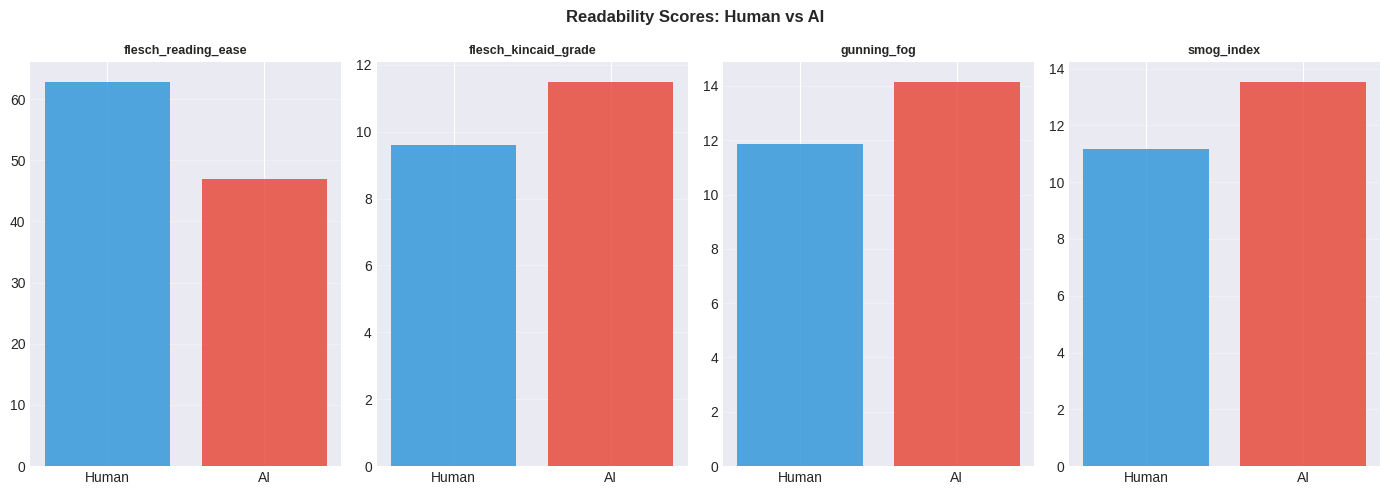


Punctuation means:
       comma_count  exclamation_count  question_count  semicolon_count  punctuation_density
label                                                                                      
AI          20.503              0.363           0.321            0.064                0.022
Human       15.745              0.260           0.770            0.216                0.021


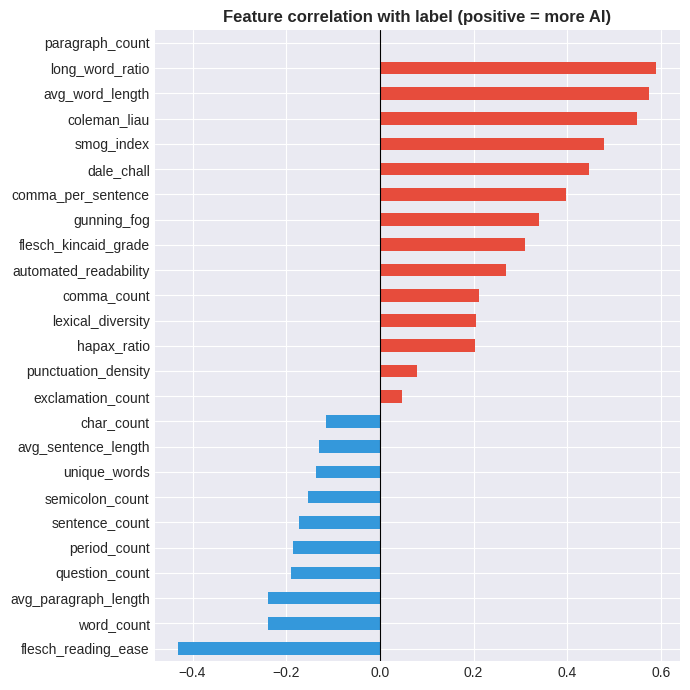


✓ STEP 3 COMPLETE


In [8]:
print("="*70)
print("STEP 3: LINGUISTIC FEATURES ANALYSIS")
print("="*70)

read_cols = ['flesch_reading_ease','flesch_kincaid_grade','gunning_fog',
             'smog_index','automated_readability','coleman_liau','dale_chall']
read_cols = [c for c in read_cols if c in df.columns]

if read_cols:
    print("\nReadability score means (Human vs AI):")
    summary = df.groupby('label')[read_cols].mean().T
    summary.columns.name = None
    print(summary.round(2).to_string())

    fig, axes = plt.subplots(1, min(4, len(read_cols)), figsize=(14, 5))
    for i, col in enumerate(read_cols[:4]):
        axes[i].bar(['Human','AI'],
                    [df[df.label=='Human'][col].mean(), df[df.label=='AI'][col].mean()],
                    color=['#3498db','#e74c3c'], alpha=0.85)
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].grid(axis='y', alpha=0.3)
    plt.suptitle('Readability Scores: Human vs AI', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/step3_readability.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("  Readability columns not found — textstat may not have run.")

# Punctuation heatmap
punct_cols = ['comma_count','exclamation_count','question_count',
              'semicolon_count','punctuation_density']
punct_cols = [c for c in punct_cols if c in df.columns]

print("\nPunctuation means:")
print(df.groupby('label')[punct_cols].mean().round(3).to_string())

# Correlation with target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'generated']
corr_with_target = df[num_cols + ['generated']].corr()['generated'].drop('generated').sort_values()

fig, ax = plt.subplots(figsize=(7, max(5, len(corr_with_target)*0.28)))
corr_with_target.plot(kind='barh', ax=ax,
                      color=['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature correlation with label (positive = more AI)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step3_correlation.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ STEP 3 COMPLETE")


## Step 4 — Content Analysis: Words, N-grams, Sentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00
STEP 4: CONTENT ANALYSIS

4.1: Word frequency analysis (CountVectorizer — fast)...

Top 15 words — HUMAN:
     word  frequency
   people     521991
 students     503430
   school     323535
      car     274212
     cars     270177
     like     247667
     just     229704
     time     227051
     help     220068
electoral     205741
     make     200337
    think     194693
  student     185337
  college     180339
     vote     166149

Top 15 words — AI:
     word  frequency
 students     344079
   people     271453
electoral     220390
     like     206620
  college     202599
     help     190162
      car     182397
     time     165081
     make     160447
important     160324
   states     151326
   school     148047
     cars     139217
     life     134813
    usage     114954


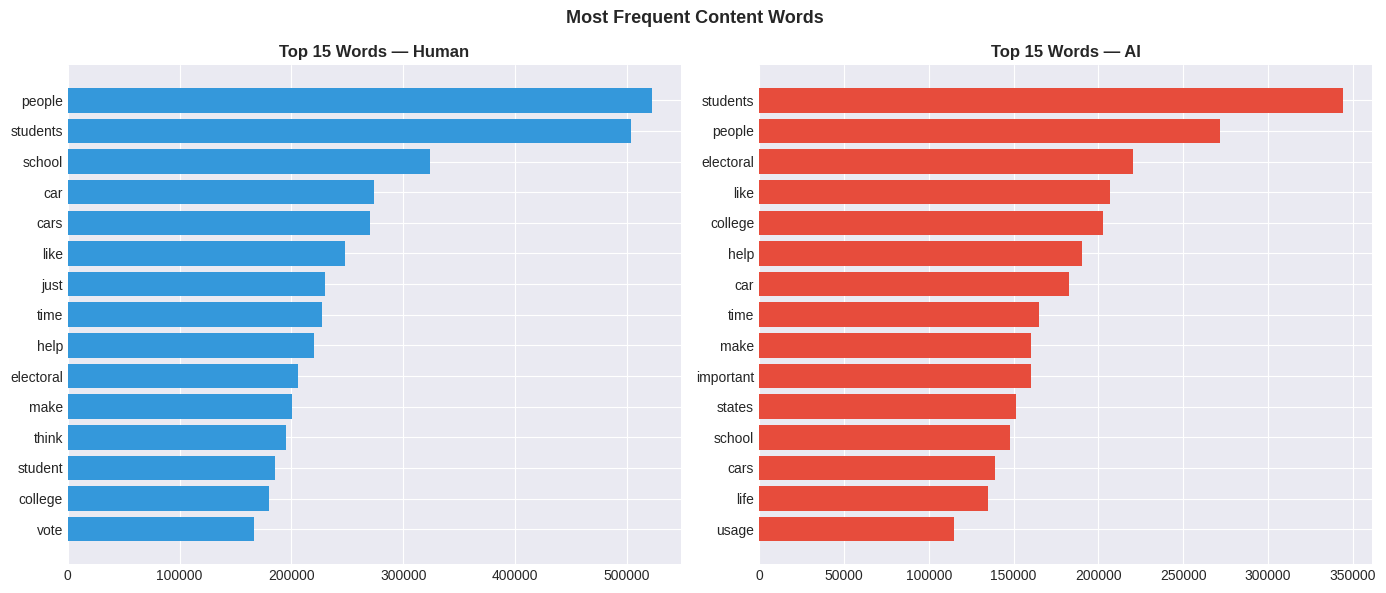


4.2: Bigram analysis...

Top bigrams — Human: ['electoral college', 'driverless cars', 'car usage', 'popular vote', 'united states', 'community service', 'cell phones', 'limiting car', 'summer projects', 'face mars']
Top bigrams — AI: ['electoral college', 'car usage', 'limiting car', 'popular vote', 'driverless cars', 'united states', 'public transportation', 'traffic congestion', 'face mars', 'high school']

4.3: Sentiment analysis (sample of 20,000)...

Sentiment means (sampled rows only):
       sentiment_positive  sentiment_negative  sentiment_compound
label                                                            
AI                    NaN                 NaN                 NaN
Human                 NaN                 NaN                 NaN

✓ STEP 4 COMPLETE


In [9]:
import sys
# Install only what's missing
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'vaderSentiment', '-q'])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

try:
    from sklearn.feature_extraction.text import CountVectorizer
except ImportError:
    pass

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print("="*70)
print("STEP 4: CONTENT ANALYSIS")
print("="*70)

stop_words = set(stopwords.words('english'))

# ── Word frequencies via CountVectorizer (much faster than NLTK per row) ─────
print("\n4.1: Word frequency analysis (CountVectorizer — fast)...")

def top_words(texts, top_k=30):
    vec = CountVectorizer(stop_words='english', max_features=top_k,
                          min_df=3, token_pattern=r"[a-zA-Z]{3,}")
    X   = vec.fit_transform(texts.dropna())
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return pd.DataFrame({'word': vocab, 'frequency': freqs}).sort_values('frequency', ascending=False)

human_words = top_words(df[df.label=='Human']['text_clean'], top_k=30)
ai_words    = top_words(df[df.label=='AI']['text_clean'],    top_k=30)

print("\nTop 15 words — HUMAN:")
print(human_words.head(15).to_string(index=False))
print("\nTop 15 words — AI:")
print(ai_words.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(human_words.head(15)['word'][::-1], human_words.head(15)['frequency'][::-1], color='#3498db')
axes[0].set_title('Top 15 Words — Human', fontweight='bold')
axes[1].barh(ai_words.head(15)['word'][::-1],    ai_words.head(15)['frequency'][::-1],    color='#e74c3c')
axes[1].set_title('Top 15 Words — AI', fontweight='bold')
plt.suptitle('Most Frequent Content Words', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step4_top_words.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Bigrams ───────────────────────────────────────────────────────────────────
print("\n4.2: Bigram analysis...")

def top_ngrams(texts, n=2, top_k=20):
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english',
                          max_features=top_k, min_df=3, token_pattern=r"[a-zA-Z]{3,}")
    X   = vec.fit_transform(texts.dropna())
    return pd.DataFrame({'ngram': vec.get_feature_names_out(),
                         'frequency': X.sum(axis=0).A1}).sort_values('frequency', ascending=False)

human_bigrams = top_ngrams(df[df.label=='Human']['text_clean'], n=2)
ai_bigrams    = top_ngrams(df[df.label=='AI']['text_clean'],    n=2)
print("\nTop bigrams — Human:", human_bigrams.head(10)['ngram'].tolist())
print("Top bigrams — AI:",    ai_bigrams.head(10)['ngram'].tolist())

# ── Sentiment (sample for speed — VADER is slow on 500K) ──────────────────────
print("\n4.3: Sentiment analysis (sample of 20,000)...")
sia = SentimentIntensityAnalyzer()
sample_idx = df.sample(n=min(20_000, len(df)), random_state=42).index

def get_sentiment(text):
    try:
        scores = sia.polarity_scores(str(text))
        return scores['pos'], scores['neg'], scores['neu'], scores['compound']
    except:
        return 0, 0, 0, 0

sent = df.loc[sample_idx, 'text_clean'].apply(get_sentiment)
df.loc[sample_idx, ['sentiment_positive','sentiment_negative',
                    'sentiment_neutral','sentiment_compound']] = pd.DataFrame(
    sent.tolist(), index=sample_idx)

# For rows not sampled, fill with NaN (honest)
for col in ['sentiment_positive','sentiment_negative','sentiment_neutral','sentiment_compound']:
    if col not in df.columns:
        df[col] = np.nan

df['sentiment_class'] = df['sentiment_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral') if pd.notna(x) else np.nan)

print("\nSentiment means (sampled rows only):")
print(df.groupby('label')[['sentiment_positive','sentiment_negative',
                             'sentiment_compound']].mean().round(3).to_string())
print("\n✓ STEP 4 COMPLETE")


## Step 5 — Statistical Tests & Final Findings

STEP 5: STATISTICAL SIGNIFICANCE TESTS

Feature                        Human μ      AI μ         p-value        Cohen d    Sig?
------------------------------------------------------------------------------------------
Essay Length (words)           419.081      344.377      0.00e+00       0.493      YES ✓
Sentence Count                 21.624       18.714       0.00e+00       0.350      YES ✓
Avg Sentence Length            20.533       19.066       0.00e+00       0.263      YES ✓
Avg Word Length                4.413        4.983        0.00e+00       -1.408     YES ✓
Lexical Diversity              0.437        0.474        0.00e+00       -0.421     YES ✓
Readability (Flesch)           62.861       46.963       0.00e+00       0.952      YES ✓
Grade Level                    9.601        11.499       0.00e+00       -0.650     YES ✓
Punctuation Density            0.021        0.022        0.00e+00       -0.160     YES ✓
Sentiment Compound             nan          nan          nan         

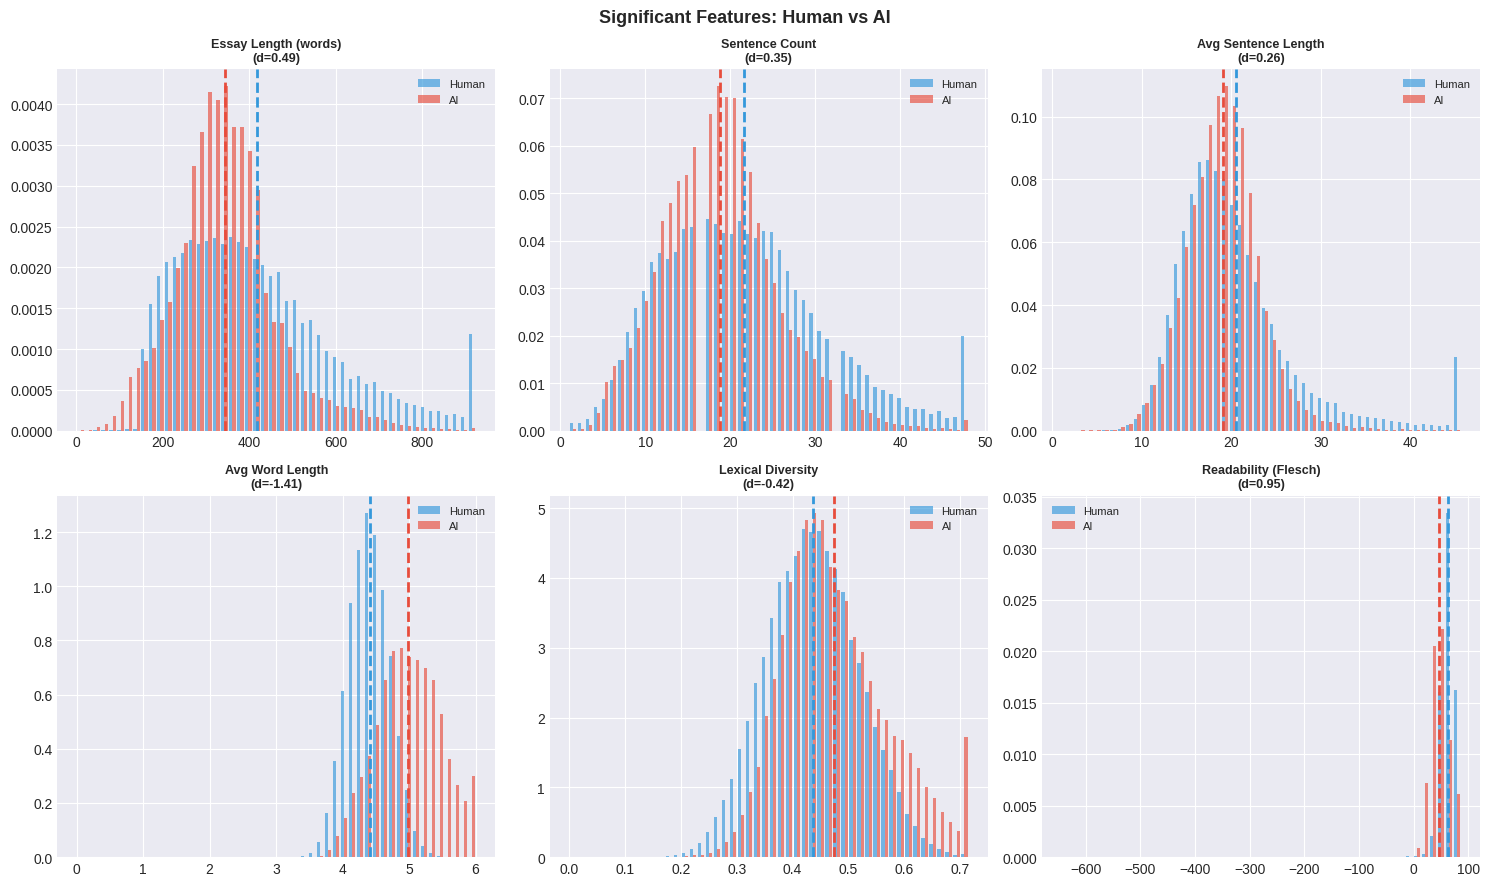


✓ STEP 5 COMPLETE


In [10]:
from scipy import stats

print("="*70)
print("STEP 5: STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

test_features = [
    ('word_count',           'Essay Length (words)'),
    ('sentence_count',       'Sentence Count'),
    ('avg_sentence_length',  'Avg Sentence Length'),
    ('avg_word_length',      'Avg Word Length'),
    ('lexical_diversity',    'Lexical Diversity'),
    ('flesch_reading_ease',  'Readability (Flesch)'),
    ('flesch_kincaid_grade', 'Grade Level'),
    ('punctuation_density',  'Punctuation Density'),
    ('sentiment_compound',   'Sentiment Compound'),
]
test_features = [(f, l) for f, l in test_features if f in df.columns]

print(f"\n{'Feature':<30} {'Human μ':<12} {'AI μ':<12} {'p-value':<14} {'Cohen d':<10} Sig?")
print("-"*90)

test_results = []
for feat, label in test_features:
    h = df[df.label=='Human'][feat].dropna()
    a = df[df.label=='AI'][feat].dropna()
    t, p = stats.ttest_ind(h, a, equal_var=False)   # Welch t-test — more robust
    pooled_std = np.sqrt(((len(h)-1)*h.std()**2 + (len(a)-1)*a.std()**2) / (len(h)+len(a)-2))
    d = (h.mean() - a.mean()) / pooled_std if pooled_std > 0 else 0
    sig = 'YES ✓' if p < 0.05 else 'no'
    print(f"{label:<30} {h.mean():<12.3f} {a.mean():<12.3f} {p:<14.2e} {d:<10.3f} {sig}")
    test_results.append({'Feature': label, 'Human_Mean': h.mean(), 'AI_Mean': a.mean(),
                         'P_Value': p, 'Cohens_D': d, 'Significant': sig})

test_df = pd.DataFrame(test_results)
print("\n✓ Statistical tests complete (Welch t-test, α=0.05)")

# ── Summary dashboard ─────────────────────────────────────────────────────────
sig_feats = [r for r in test_results if r['Significant'] == 'YES ✓']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, row in enumerate(sig_feats[:6]):
    feat = next(f for f, l in test_features if l == row['Feature'])
    axes[i].hist([df[df.label=='Human'][feat].dropna(),
                  df[df.label=='AI'][feat].dropna()],
                 bins=50, alpha=0.65, color=['#3498db','#e74c3c'], label=['Human','AI'], density=True)
    axes[i].axvline(row['Human_Mean'], color='#3498db', lw=2, ls='--')
    axes[i].axvline(row['AI_Mean'],    color='#e74c3c', lw=2, ls='--')
    axes[i].set_title(f"{row['Feature']}\n(d={row['Cohens_D']:.2f})", fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=8)
for j in range(i+1, 6): axes[j].set_visible(False)
plt.suptitle('Significant Features: Human vs AI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step5_significant_features.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ STEP 5 COMPLETE")


## Step 6 — ML Classification Model

STEP 6: ML CLASSIFICATION
Train: 290,300  |  Test: 72,576  |  Features: 25

  Training Logistic Regression...
    ACC=0.8799  F1=0.8806  AUC=0.9515

  Training Random Forest...
    ACC=0.9571  F1=0.9568  AUC=0.9920

  Training XGBoost...
    ACC=0.9399  F1=0.9396  AUC=0.9868


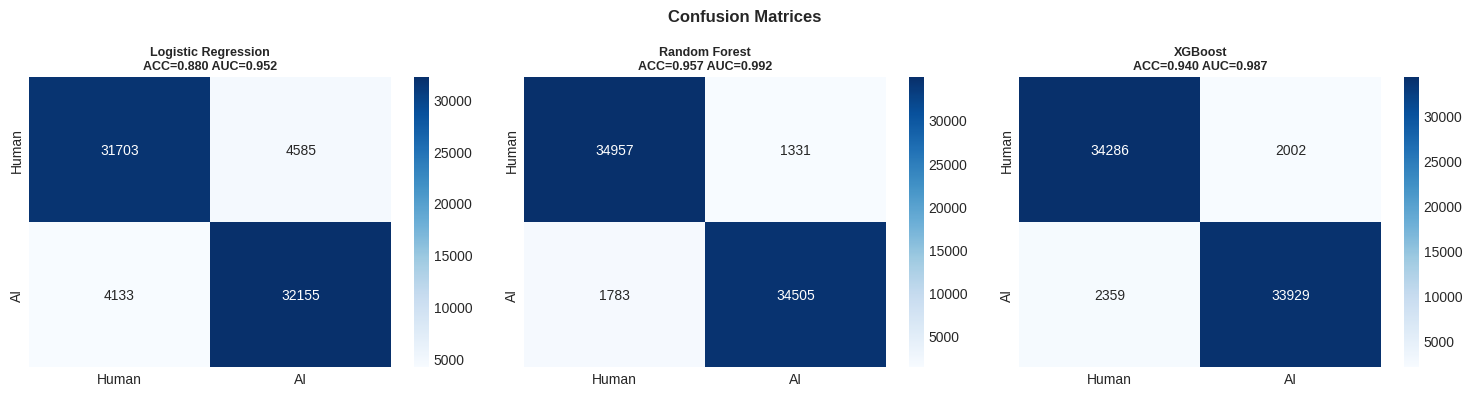

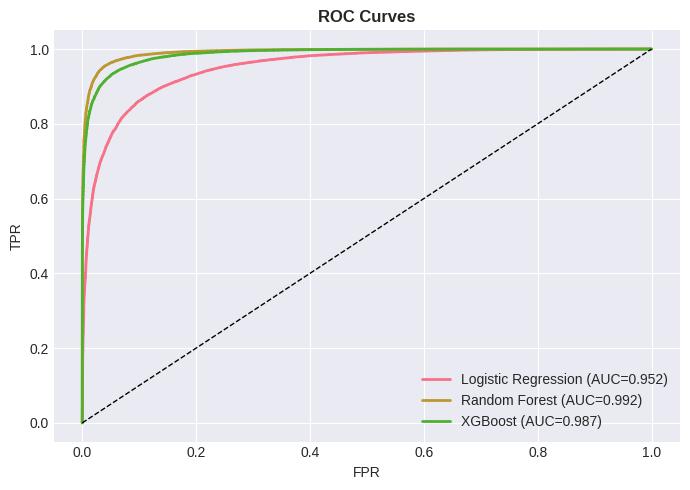

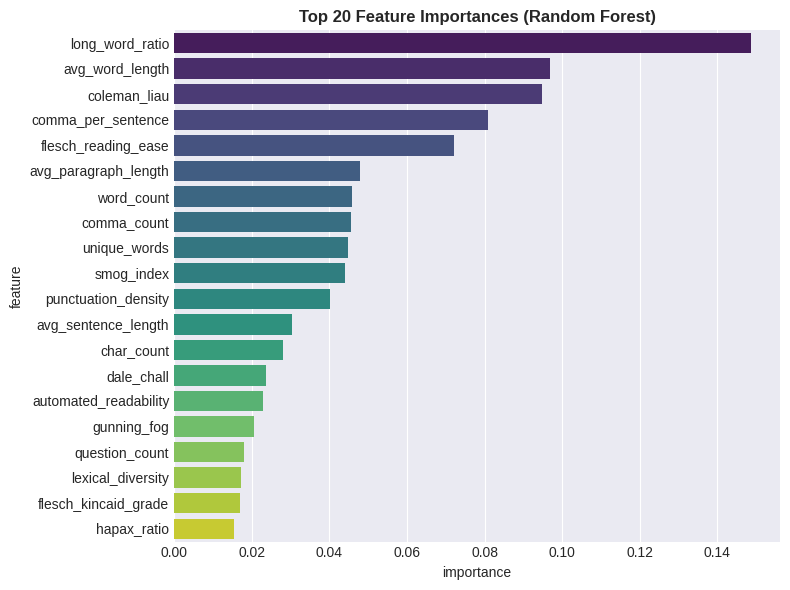


  TF-IDF + Logistic Regression (text baseline)...
    TF-IDF LR  ACC=0.9985  AUC=1.0000

Model summary:
              Model  Accuracy     F1    AUC  Precision  Recall
Logistic Regression    0.8799 0.8806 0.9515     0.8752  0.8861
      Random Forest    0.9571 0.9568 0.9920     0.9629  0.9509
            XGBoost    0.9399 0.9396 0.9868     0.9443  0.9350
          TF-IDF LR    0.9985 0.9985 1.0000     0.9991  0.9979

✓ STEP 6 COMPLETE


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score, confusion_matrix, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping. Run: pip install xgboost")

print("="*70)
print("STEP 6: ML CLASSIFICATION")
print("="*70)

# ── Feature-based models ──────────────────────────────────────────────────────
feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in ('generated',) and df[c].notna().sum() > len(df)*0.5]
X = df[feat_cols].fillna(0)
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Features: {len(feat_cols)}")

models = {
    'Logistic Regression': Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15,
                                             min_samples_leaf=5, random_state=42,
                                             n_jobs=-1, class_weight='balanced'),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8,
                                       eval_metric='logloss', random_state=42, n_jobs=-1)

all_metrics   = []
all_pred_cols = pd.DataFrame({'true': y_test.values,
                               'true_label': y_test.map({0:'Human',1:'AI'}).values})

fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
if len(models) == 1: axes = [axes]

for idx, (name, model) in enumerate(models.items()):
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:,1]
    acc  = accuracy_score(y_test, yp)
    f1   = f1_score(y_test, yp)
    auc  = roc_auc_score(y_test, yprob)
    print(f"    ACC={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    all_metrics.append({'Model': name, 'Accuracy': round(acc,4), 'F1': round(f1,4),
                        'AUC': round(auc,4),
                        'Precision': round(precision_score(y_test,yp),4),
                        'Recall': round(recall_score(y_test,yp),4)})
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues',
                xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    axes[idx].set_title(f'{name}\nACC={acc:.3f} AUC={auc:.3f}', fontsize=9, fontweight='bold')
    col = name.replace(' ','_').lower()
    all_pred_cols[f'{col}_pred']     = yp
    all_pred_cols[f'{col}_prob_ai']  = yprob.round(4)
    all_pred_cols[f'{col}_pred_lbl'] = pd.Series(yp).map({0:'Human',1:'AI'}).values

plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step6_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

# ROC curves
plt.figure(figsize=(7,5))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves', fontweight='bold'); plt.legend()
plt.tight_layout()
plt.savefig('plots/step6_roc.png', dpi=200, bbox_inches='tight')
plt.show()

# Feature importance (RF)
rf = models['Random Forest']
fi_df = pd.DataFrame({'feature': feat_cols, 'importance': rf.feature_importances_}
                    ).sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/step6_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

# ── TF-IDF text baseline ──────────────────────────────────────────────────────
print("\n  TF-IDF + Logistic Regression (text baseline)...")
texts_train = df.loc[X_train.index, 'text_clean']
texts_test  = df.loc[X_test.index,  'text_clean']
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1,2), sublinear_tf=True, min_df=3)
lr_tfidf = LogisticRegression(max_iter=1000, C=5.0, n_jobs=-1, random_state=42)
lr_tfidf.fit(tfidf.fit_transform(texts_train), y_train)
yp_t   = lr_tfidf.predict(tfidf.transform(texts_test))
yprob_t = lr_tfidf.predict_proba(tfidf.transform(texts_test))[:,1]
acc_t   = accuracy_score(y_test, yp_t)
auc_t   = roc_auc_score(y_test, yprob_t)
print(f"    TF-IDF LR  ACC={acc_t:.4f}  AUC={auc_t:.4f}")
all_metrics.append({'Model':'TF-IDF LR','Accuracy':round(acc_t,4),
                    'F1':round(f1_score(y_test,yp_t),4),'AUC':round(auc_t,4),
                    'Precision':round(precision_score(y_test,yp_t),4),
                    'Recall':round(recall_score(y_test,yp_t),4)})
all_pred_cols['tfidf_lr_pred_lbl'] = pd.Series(yp_t).map({0:'Human',1:'AI'}).values
all_pred_cols['tfidf_lr_prob_ai']  = yprob_t.round(4)

metrics_df = pd.DataFrame(all_metrics)
print("\nModel summary:")
print(metrics_df.to_string(index=False))
print("\n✓ STEP 6 COMPLETE")


## Step 7 — Power BI Exports

In [12]:
print("="*70)
print("STEP 7: POWER BI EXPORTS")
print("="*70)

# 1. Main essay features
pbi_cols = ['generated','label','char_count','word_count','unique_words',
            'sentence_count','paragraph_count','avg_word_length','avg_sentence_length',
            'avg_paragraph_length','lexical_diversity','hapax_ratio','long_word_ratio',
            'comma_count','period_count','exclamation_count','question_count',
            'semicolon_count','punctuation_density','comma_per_sentence',
            'flesch_reading_ease','flesch_kincaid_grade','gunning_fog',
            'smog_index','automated_readability','coleman_liau','dale_chall',
            'sentiment_positive','sentiment_negative','sentiment_neutral',
            'sentiment_compound','sentiment_class']
pbi_cols = [c for c in pbi_cols if c in df.columns]
df[pbi_cols].replace([np.inf,-np.inf], np.nan).to_csv('powerbi_exports/PBI_01_essay_features.csv', index=False)
print("✓ PBI_01_essay_features.csv")

# 2. Summary stats
summ = []
for col in [c for c in pbi_cols if c not in ('generated','label','sentiment_class')]:
    for lbl in ['Human','AI']:
        s = df[df.label==lbl][col].dropna()
        summ.append({'Metric':col,'Label':lbl,'Mean':s.mean(),'Median':s.median(),
                     'Std':s.std(),'Min':s.min(),'Max':s.max(),'Count':len(s)})
pd.DataFrame(summ).to_csv('powerbi_exports/PBI_02_summary_stats.csv', index=False)
print("✓ PBI_02_summary_stats.csv")

# 3 & 4. Word frequencies (already computed)
human_wf = top_words(df[df.label=='Human']['text_clean'], top_k=150)
ai_wf    = top_words(df[df.label=='AI']['text_clean'],    top_k=150)
human_wf['label'] = 'Human'; ai_wf['label'] = 'AI'
pd.concat([human_wf, ai_wf]).to_csv('powerbi_exports/PBI_03_word_freq.csv', index=False)
print("✓ PBI_03_word_freq.csv")

human_bg = top_ngrams(df[df.label=='Human']['text_clean'], n=2, top_k=100)
ai_bg    = top_ngrams(df[df.label=='AI']['text_clean'],    n=2, top_k=100)
human_bg['label'] = 'Human'; ai_bg['label'] = 'AI'
pd.concat([human_bg, ai_bg]).to_csv('powerbi_exports/PBI_04_bigrams.csv', index=False)
print("✓ PBI_04_bigrams.csv")

# 5. Model metrics
metrics_df.to_csv('powerbi_exports/PBI_05_model_metrics.csv', index=False)
print("✓ PBI_05_model_metrics.csv")

# 6. Predictions + confidence
all_pred_cols.to_csv('powerbi_exports/PBI_06_predictions.csv', index=False)
print("✓ PBI_06_predictions.csv")

# 7. Statistical test results
test_df.to_csv('powerbi_exports/PBI_07_stat_tests.csv', index=False)
print("✓ PBI_07_stat_tests.csv")

# 8. Feature importance
fi_df.to_csv('powerbi_exports/PBI_08_feature_importance.csv', index=False)
print("✓ PBI_08_feature_importance.csv")

print("\n📁 All files in: ./powerbi_exports/")
print("\n✓ ALL EXPORTS COMPLETE")


STEP 7: POWER BI EXPORTS
✓ PBI_01_essay_features.csv
✓ PBI_02_summary_stats.csv
✓ PBI_03_word_freq.csv
✓ PBI_04_bigrams.csv
✓ PBI_05_model_metrics.csv
✓ PBI_06_predictions.csv
✓ PBI_07_stat_tests.csv
✓ PBI_08_feature_importance.csv

📁 All files in: ./powerbi_exports/

✓ ALL EXPORTS COMPLETE


## Bonus — LinkedIn Cards


In [13]:
import plotly.graph_objects as go

# FIX 5: read values from df instead of hardcoding them
human_df = df[df.label == 'Human']
ai_df    = df[df.label == 'AI']

cards = [
    ("Essay Length (Words)",    human_df['word_count'].mean(),          ai_df['word_count'].mean()),
    ("Readability (Flesch Ease)",
     human_df['flesch_reading_ease'].mean() if 'flesch_reading_ease' in df.columns else 0,
     ai_df['flesch_reading_ease'].mean()    if 'flesch_reading_ease' in df.columns else 0),
    ("Sentiment Compound Score",
     human_df['sentiment_compound'].mean() if 'sentiment_compound' in df.columns else 0,
     ai_df['sentiment_compound'].mean()    if 'sentiment_compound' in df.columns else 0),
]

def linkedin_card(title, human_val, ai_val):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=['Human','AI'],
        y=[round(human_val,2), round(ai_val,2)],
        marker_color=['#3498db','#e74c3c'],
        text=[round(human_val,2), round(ai_val,2)],
        textposition='auto',
        textfont=dict(size=18, color='white')
    ))
    fig.update_layout(
        title=dict(text=f"<b>{title}</b><br><sup>Human (blue) vs AI (red)</sup>",
                   x=0.5, font=dict(size=18)),
        height=500, width=480,
        template='plotly_white',
        yaxis=dict(showgrid=True, gridcolor='lightgrey'),
        margin=dict(l=40, r=40, t=80, b=40)
    )
    fig.show()

for title, h, a in cards:
    linkedin_card(title, h, a)
    print(f"  {title}: Human={h:.2f}  AI={a:.2f}")

print("\n✓ LinkedIn cards generated from computed data")


  Essay Length (Words): Human=419.08  AI=344.38


  Readability (Flesch Ease): Human=62.86  AI=46.96


  Sentiment Compound Score: Human=nan  AI=nan

✓ LinkedIn cards generated from computed data
